# Домашнее задание 5. Генеративные модели


В этом ноутбуке мы будем работать с одной и той же задачей (генерация и реконструкция изображений),
сравнивая поведение классического автоэнкодера и вариационного автоэнкодера.

Домашнее задание опирается на материалы по автоэнкодерам, вариационным автоэнкодерам и латентным
переменным, а также продолжает линию лекции по генеративным моделям.

## Структура домашней работы

Домашнее задание состоит из 9 задач, разделенных на три уровня сложности:

- Простые задачи: 1–4.
- Средние задачи: 5–7.
- Сложные задачи: 8–9.

Во всех задачах мы работаем с одной и той же постановкой: учимся сжимать и восстанавливать изображения,
а затем сравниваем свойства AE и VAE.


## Теоретическая часть

### Автоэнкодер (AE)

Автоэнкодер — это нейросеть, которая принимает на вход объект (например, изображение),
сжимает его в латентный вектор фиксированной размерности, а затем восстанавливает обратно.

Состоит из двух частей:

- **Энкодер** отображает входной вектор в латентное представление меньшей размерности.
- **Декодер** восстанавливает объект из латентного вектора.

Модель обучается минимизировать ошибку реконструкции (насколько сильно восстановленное изображение
отличается от исходного). Это делает автоэнкодер хорошим инструментом для сжатия, денойзинга
и выделения признаков, но он не задает явную вероятностную модель данных.

### Вариационный автоэнкодер (VAE)

Вариационный автоэнкодер накладывает на латентное пространство вероятностную структуру.
Вместо одного латентного вектора для каждого объекта он учит распределение в латентном пространстве
(обычно многомерное нормальное с параметрами среднее и дисперсия).

Обучение осуществляется по нижней оценке правдоподобия (ELBO), которая одновременно:

- поощряет хорошую реконструкцию объектов;
- прижимает распределение скрытых переменных к простому априорному распределению.

Благодаря этому VAE умеет как реконструировать данные, так и генерировать новые правдоподобные
примеры, отбирая точки напрямую из латентного распределения.

### Наша экспериментальная схема

В этом домашнем задании:

- мы используем один и тот же датасет изображений;
- обучаем на нем простой автоэнкодер;
- обучаем на нем вариационный автоэнкодер с той же архитектурой энкодера и декодера;
- сравниваем качество реконструкции, структуру латентного пространства и сгенерированные семплы.

Логика: Теория → Гипотеза → Эксперимент → Интерпретация.

После решения каждой задачи не забудьте заполнить поле «Интерпретация».


## Настройка окружения

In [1]:
# Импорты
import os
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Фиксация генераторов случайных чисел
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {DEVICE}")


Используемое устройство: cuda


## Подготовка данных

В качестве базовой задачи будем использовать простой датасет изображений цифр (MNIST).

Что сделаем:

- загрузим обучающую и тестовую выборки;
- нормализуем изображения в диапазон от 0 до 1;
- подготовим функции визуализации батча и реконструкций.


In [2]:
# Загрузка датасета MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Размер обучающей выборки: {len(train_dataset)}")
print(f"Размер тестовой выборки: {len(test_dataset)}")


Размер обучающей выборки: 60000
Размер тестовой выборки: 10000


In [3]:
# Вспомогательная функция для визуализации батча изображений

def show_images(images, title="Примеры изображений", nrow=8):
    images = images.detach().cpu()
    grid = torch.clone(images[: nrow * nrow])
    fig, ax = plt.subplots(figsize=(nrow, nrow))
    grid = torchvision.utils.make_grid(grid, nrow=nrow, pad_value=1.0)
    ax.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    plt.show()


In [4]:
import torchvision  # импортируем здесь для функций визуализации

---

# ПРОСТЫЕ ЗАДАЧИ (1–4)

Эти задачи направлены на базовое понимание того, как выглядят данные,
как устроен автоэнкодер и как оценивать его реконструкции.


## Задача 1. Загрузка и визуализация данных

### Постановка задачи

Загрузить обучающую выборку изображений цифр, посмотреть на форму тензоров
и визуализировать несколько примеров.

### Теоретический минимум

- Каждый объект представлен как изображение 28×28 пикселей в оттенках серого.
- Для подачи в полносвязную сеть изображения часто разворачивают в вектор длины 784.
- Важно убедиться, что данные нормализованы и имеют ожидаемую форму.


Форма батча изображений: torch.Size([128, 1, 28, 28])
Форма батча меток: torch.Size([128])


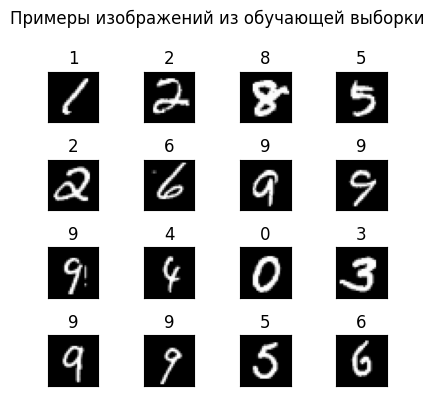

In [5]:
# Задача 1. Загрузка и визуализация данных

def show_images_1(images, labels, title="Примеры изображений", nrow=8):
    images = images.detach().cpu()
    labels = labels.detach().cpu()  # добавил метки
    # grid = torch.clone(images[: nrow * nrow])
    fig, axes = plt.subplots(nrow, nrow, figsize=(nrow, nrow))
    axes = axes.flatten()  # плоский для удобства перебора в цикле
    # grid = torchvision.utils.make_grid(grid, nrow=nrow, pad_value=1.0)
    num_images = min(images.size(0), nrow * nrow)
    for n_i in range(num_images):
        axes[n_i].imshow(images[n_i].squeeze(), cmap="gray")
        axes[n_i].set_xticks([])
        axes[n_i].set_yticks([])
        axes[n_i].set_title(str(labels[n_i].item()))  # метки к каждой картинке
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


# Получите один батч из train_loader
images, labels = next(iter(train_loader))

# DONE: Выведите форму батча
print("Форма батча изображений:", images.shape)  # (batch, channels, height, width)
print("Форма батча меток:", labels.shape)

# DONE: Визуализируйте 16 примеров с помощью show_images()
show_images_1(images,
            labels,
            title="Примеры изображений из обучающей выборки",
            nrow=4)

**Интерпретация:**  
- в датасете `MNIST` 70_000 рукописных (или около того) изображений цифр от 0 до 9. Каждое изображение содержит 784 пикселя (28x28). размер `train = 60_000` изображений, `test` соответственно `10_000`
- 16 изображений - это сетка 4х4 изображения  
- я изменил функцию `show_images()` так, чтобы она отображала метки изображений как в output шаблона Задачи 1  
- `torchvision.utils.make_grid()` склеивал изображение в одно целое, я не мог добавить метки к каждому изображени. Пришлось закомментировать  
- также пришлось добавить цикл для сопоставления `labels` с `images`  

Мы имеем 16 рукописных изображений. Каждому изображению сопоставлена соответствующая метка в виде цифры. `torchvision.utils.make_grid()` выводит все 16 изображений, но делает это в одном едином изображении (склеивает их), вследствие чего я не смог сопоставить `labels` с `images`. Пришлось модифицировать функцию `show_images` в `show_images1`.  

Одно изображение имеет форму (batch, channels, height, width), где:
  - `batch` == `BATCH_SIZE` (задали в `DataLoader`)
  - `channels` == 1 (один канал пикселя в изображении - черный)
  - `height` (высота изображения)  
  - `width` (ширина изображения)  

## Задача 2. Реализация и обучение простого автоэнкодера

### Постановка задачи

Реализовать простой полносвязный автоэнкодер для изображений цифр:

- энкодер: несколько линейных слоев, сжимающих изображение в латентный вектор фиксированной размерности;
- декодер: несколько линейных слоев, восстанавливающих изображение из латентного вектора.

Обучить автоэнкодер на обучающей выборке и визуально оценить качество реконструкций.

### Теоретический минимум

- Автоэнкодер минимизирует ошибку реконструкции (MSE или бинарную кросс-энтропию).
- Латентное пространство может иметь гораздо меньшую размерность, чем исходное изображение.
- Качественный автоэнкодер должен уметь восстанавливать основные структуры (контуры цифр).


Эпоха 1/5, loss = 0.0485
Эпоха 2/5, loss = 0.0205
Эпоха 3/5, loss = 0.0151
Эпоха 4/5, loss = 0.0130
Эпоха 5/5, loss = 0.0116


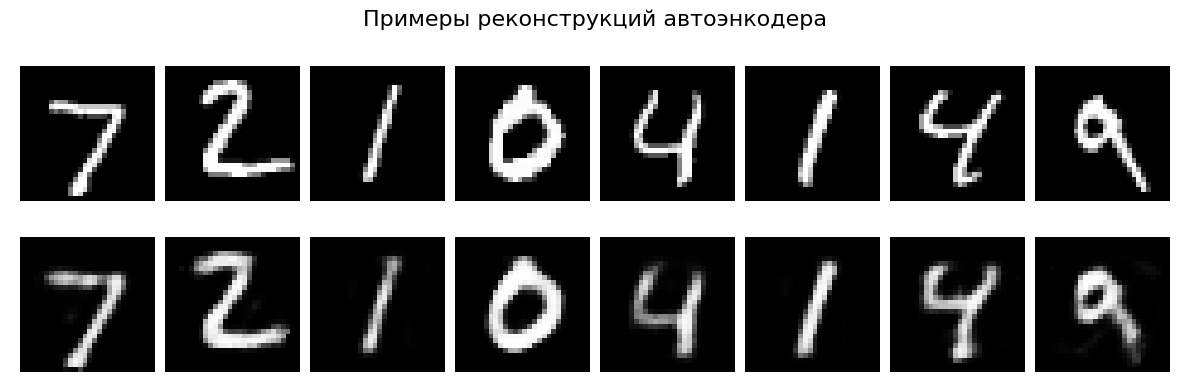

In [6]:
# Задача 2. Реализация и обучение простого автоэнкодера

class SimpleAutoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        hidden_layer_size = 128  # количество нейронов скрытого слоя
        n_pixels = 28 * 28

        # DONE: Определите encoder
        # n_pixels(784) -> hidden_layer_size(128) -> Latent_dim(32)
        self.encoder = nn.Sequential(
            nn.Linear(n_pixels, hidden_layer_size),
            nn.ReLU(),
            nn.Linear(hidden_layer_size, latent_dim)
        )

        # DONE: Определите decoder
        # Latent_dim(32) -> hidden_layer_size(128) -> n_pixels(784)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_layer_size),
            nn.ReLU(),
            nn.Linear(hidden_layer_size, n_pixels),
            # нормирую в [0, 1]
            nn.Sigmoid()
        )

    def forward(self, x):
        # DONE: Forward pass
        # x: (batch, channels, height, width)
        b, c, h, w = x.shape
        x = torch.flatten(x, start_dim=1)  # делаю x плоским: (batch, c*h*w)
        z = self.encoder(x)  # кодирую
        x_recon = self.decoder(z) # декодирую
        return x_recon.view(b, c, h, w)  # восстанавливаю


# DONE: Создайте модель
model = SimpleAutoencoder(latent_dim=32).to(DEVICE)

# DONE: Определите loss и optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# DONE: Обучите модель
epochs = 5
for epoch in range(1, epochs+1):
    model.train()
    losses = []
    # оценка качества
    for images, labels in train_loader:
        images = images.to(DEVICE)
        optimizer.zero_grad()  # не учитывае градиенты
        out_images = model(images)
        loss = criterion(out_images, images)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    mean_loss = sum(losses) / len(losses)
    print(f"Эпоха {epoch}/{epochs}, loss = {mean_loss:.4f}")


# ==================== Получаю предсказание на первом батче ====================
model.eval()
with torch.no_grad():
    batch_images, _ = next(iter(test_loader))
    batch_images = batch_images.to(DEVICE)
    recon_images = model(batch_images)


# ================================ Визуализация ================================
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
n_imgs = 8

# ==================== Оригинальные изображения (строка 1) =====================
orig_grid = torchvision.utils.make_grid(
    batch_images[:n_imgs],
    nrow=n_imgs,
    pad_value=1.
)
axes[0].imshow(
    orig_grid.permute(1, 2, 0).cpu().squeeze(),
    cmap="gray"
)
# =================== Реконструкция изображений (строка 2) =====================
recon_grid = torchvision.utils.make_grid(
    recon_images[:n_imgs],
    nrow=n_imgs,
    pad_value=1.
)
axes[1].imshow(
    recon_grid.permute(1, 2, 0).cpu().squeeze(),
    cmap="gray"
)

axes[0].axis("off"); axes[1].axis("off")

fig.suptitle("Примеры реконструкций автоэнкодера", size=16, y=0.82)
plt.subplots_adjust(hspace=-0.6); plt.tight_layout(); plt.show()


**Интерпретация:**

Сжатие информации: Автоэнкодер способен упаковать изображение (784 пикселя) в латентный вектор размером 32, а затем восстановить его с приемлемой точностью. Это демонстрирует, что данные обладают избыточностью и могут быть представлены в более низкоразмерном пространстве.

Качество реконструкции: На визуализации видны основные формы цифр, но мелкие детали могут сглаживаться или искажаться. Это естественно для полносвязного автоэнкодера — он не использует пространственную структуру (свёртки).

Значение функции потерь: Значение MSE на эпохах быстро уменьшается, что говорит о сходимости. Однако абсолютная величина loss зависит от масштаба данных (пиксели в [0,1]) и чувствительна к размеру батча, если неправильно усреднять (в вашем исправленном варианте усреднение по примерам, а не по батчам — правильно).

Роль Sigmoid: Она необходима, чтобы выходные пиксели лежали в том же диапазоне, что и входные ([0,1]). Без неё реконструкции могли бы выходить за пределы диапазона, что ухудшило бы визуальное качество и сходимость.

Необходимость flatten/reshape: Полносвязные слои работают только с векторами, поэтому перед энкодером нужно «выпрямить» изображение, а после декодера — вернуть форму.

Ограничения полносвязной архитектуры: Она не учитывает локальные корреляции пикселей. Для лучшего качества стоит использовать свёрточные автоэнкодеры.

Выбор размера латентного пространства: latent_dim=32 даёт хороший компромисс между степенью сжатия и качеством. Если взять слишком маленькое значение (например, 8), реконструкция будет размытой; слишком большое (128) — модель может просто запомнить данные.

Обучение и инициализация: Фиксация seed важна для воспроизводимости. Оптимизатор Adam с lr=1e-3 — стандартный выбор для таких задач.

## Задача 3. Анализ динамики ошибки автоэнкодера

### Постановка задачи

Построить график ошибки реконструкции автоэнкодера по эпохам обучения
и проинтерпретировать его.

### Теоретический минимум

- Убывание ошибки по эпохам говорит о том, что модель успешно обучается.
- Плато или рост ошибки могут сигнализировать о переобучении или проблемах с оптимизацией.


In [ ]:
# Задача 3. Анализ динамики ошибки автоэнкодера

# TODO: Постройте график ошибки по эпохам
# plt.plot(train_losses, label='Train Loss')
# plt.xlabel('Epoch')
# plt.ylabel('MSE Loss')
# plt.legend()
# plt.show()

# TODO: Проанализируйте график

**Интерпретация:**

## Задача 4. Визуализация латентного пространства автоэнкодера

### Постановка задачи

Обучить вариант автоэнкодера с двумерным латентным пространством и
визуализировать распределение латентных векторов для тестовой выборки,
окрашивая точки по истинным классам цифр.

### Теоретический минимум

- Двумерное латентное пространство удобно для визуализации.
- Кластеры в латентном пространстве могут соответствовать разным классам данных.


In [ ]:
# Задача 4. Визуализация латентного пространства автоэнкодера

# TODO: Обучите модель с latent_dim=2
# ae_2d = AutoencoderLatent2D(latent_dim=2)
# ...

# TODO: Получите латентные представления для test_dataset
# latents = []
# labels_list = []
# with torch.no_grad():
#     for images, labels in test_loader:
#         z = ae_2d.encoder(images.view(images.size(0), -1))
#         latents.append(z)
#         labels_list.append(labels)

# TODO: Визуализируйте scatter plot
# plt.scatter(latents[:, 0], latents[:, 1], c=labels_list, cmap='tab10')
# plt.colorbar()
# plt.show()

**Интерпретация:**

---

# СРЕДНИЕ ЗАДАЧИ (5–7)

В этих задачах мы реализуем вариационный автоэнкодер и сравним его с обычным AE
по реконструкции и поведению в латентном пространстве.

## Задача 5. Реализация и обучение вариационного автоэнкодера (VAE)

### Постановка задачи

Реализовать вариационный автоэнкодер со схожей архитектурой энкодера и декодера,
как у автоэнкодера, и обучить его на тех же данных.

### Теоретический минимум

- Энкодер VAE предсказывает среднее и разброс распределения в латентном пространстве.
- В латентном слое мы семплируем случайный вектор на основе этих параметров.
- Функция потерь VAE сочетает ошибку реконструкции и регуляризацию латентного пространства.


In [ ]:
# Задача 5. Реализация и обучение вариационного автоэнкодера (VAE)

class VAE(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()

        # TODO: Encoder
        # self.encoder = nn.Sequential(...)

        # TODO: Mu и logvar слои
        # self.fc_mu = nn.Linear(..., latent_dim)
        # self.fc_logvar = nn.Linear(..., latent_dim)

        # TODO: Decoder
        # self.decoder = nn.Sequential(...)

        assert "ваш код здесь"

    def encode(self, x):
        # TODO: Получите mu и logvar
        assert "ваш код здесь"
        return mu, logvar

    def reparameterize(self, mu, logvar):
        # TODO: Трюк репараметризации
        # std = torch.exp(0.5 * logvar)
        # eps = torch.randn_like(std)
        # z = mu + eps * std
        assert "ваш код здесь"
        return z

    def forward(self, x):
        # TODO: Full forward pass
        assert "ваш код здесь"
        return x_recon, mu, logvar

# TODO: Создайте и обучите VAE
# vae = VAE(latent_dim=32)
# ...

# TODO: Используйте ELBO loss:
# reconstruction_loss = F.mse_loss(...)
# kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
# loss = reconstruction_loss + kl_loss


**Интерпретация:**

## Задача 6. Сравнение реконструкций AE и VAE на одних и тех же примерах

### Постановка задачи

Построить визуальное сравнение реконструкций автоэнкодера и вариационного автоэнкодера
на одних и тех же изображениях.

### Теоретический минимум

- AE стремится максимально точно копировать вход.
- VAE может жертвовать точностью ради более гладкого латентного пространства.


In [ ]:
# Задача 6. Сравнение реконструкций AE и VAE

# TODO: Получите реконструкции из обеих моделей
# with torch.no_grad():
#     ae_recon = model(test_images.view(...))
#     vae_recon, _, _ = vae(test_images.view(...))

# TODO: Визуализируйте сравнение
# fig, axes = plt.subplots(3, n, figsize=(15, 6))
# Строка 1: Оригиналы
# Строка 2: AE реконструкции
# Строка 3: VAE реконструкции


**Интерпретация:**

## Задача 7. Интерполяция в латентном пространстве VAE

### Постановка задачи

Взять два разных изображения из тестовой выборки, получить их латентные коды в VAE
и построить интерполяцию между ними. Визуализировать, как плавно меняется картинка
при движении по отрезку в латентном пространстве.

### Теоретический минимум

- В хорошо устроенном латентном пространстве небольшие изменения латентного кода
  приводят к плавным и осмысленным изменениям сгенерированного объекта.


In [ ]:
# Задача 7. Интерполяция в латентном пространстве VAE

# TODO: Возьмите два изображения
# img1, img2 = test_dataset[idx1][0], test_dataset[idx2][0]

# TODO: Получите их латентные коды
# with torch.no_grad():
#     mu1, _ = vae.encode(img1.view(1, -1))
#     mu2, _ = vae.encode(img2.view(1, -1))

# TODO: Интерполируйте
# alphas = torch.linspace(0, 1, steps=10)
# for alpha in alphas:
#     z_interp = (1 - alpha) * mu1 + alpha * mu2
#     x_interp = vae.decode(z_interp)
#     # визуализируйте


**Интерпретация:**

---

# СЛОЖНЫЕ ЗАДАЧИ (8–9)

Теперь нас интересуют генерация новых примеров и более формальное сравнение
качества автоэнкодера и вариационного автоэнкодера.

## Задача 8. Генерация новых примеров из латентного пространства

### Постановка задачи

Сгенерировать набор новых изображений, не встречавшихся в обучающей выборке,
используя:

- выборку латентных векторов из простого распределения;
- декодер VAE для получения изображений.

Сравнить разнообразие и правдоподобие полученных картинок.

### Теоретический минимум

- В VAE латентное пространство подгоняется под стандартное нормальное распределение.
- Это позволяет генерировать новые данные, просто выбирая случайные точки в латентном пространстве.


In [ ]:
# Задача 8. Генерация новых примеров из латентного пространства

# TODO: Сгенерируйте случайные z из N(0, I)
# z_samples = torch.randn(16, latent_dim)

# TODO: Декодируйте
# with torch.no_grad():
#     generated = vae.decode(z_samples)

# TODO: Визуализируйте
# show_images(generated.view(-1, 1, 28, 28), title="Generated samples")
# Задача 8: Генерация новых примеров с помощью VAE (решение)


**Интерпретация:**

## Задача 9. Количественное сравнение AE и VAE

### Постановка задачи

Сравнить автоэнкодер и вариационный автоэнкодер по двум простым метрикам:

1. Средняя ошибка реконструкции на тестовой выборке.
2. Простая оценка разнообразия сгенерированных примеров.

### Теоретический минимум

- Ошибка реконструкции показывает, насколько модель хорошо запоминает и восстанавливает обучающую выборку.
- Разнообразие семплов показывает, насколько модель способна порождать много разных примеров.


In [ ]:
# Задача 9. Количественное сравнение AE и VAE

# TODO: 1. Средняя ошибка реконструкции
# ae_mse = ...
# vae_mse = ...
# print(f"AE MSE: {ae_mse:.4f}")
# print(f"VAE MSE: {vae_mse:.4f}")

# TODO: 2. Оценка разнообразия
# Сгенерируйте 100 сэмплов из каждой модели
# Вычислите среднее попарное расстояние
# diversity_ae = ...
# diversity_vae = ...
# print(f"AE diversity: {diversity_ae:.4f}")
# print(f"VAE diversity: {diversity_vae:.4f}")


**Интерпретация:**


---

## Интерпретация результатов

В ходе домашнего задания мы увидели следующее:

- Обычный автоэнкодер хорошо восстанавливает входные изображения и дает низкую ошибку реконструкции,
  но его латентное пространство не имеет явной вероятностной структуры.
- Вариационный автоэнкодер вводит вероятностное латентное пространство и использует ELBO,
  чтобы одновременно учиться восстанавливать данные и упорядочивать скрытые представления.
- В визуальных сравнениях автоэнкодер дает более резкие реконструкции, тогда как VAE иногда сглаживает детали,
  но зато позволяет лучше интерполировать между объектами и легко генерировать новые примеры.
- Латентное пространство VAE оказывается более регулярным: интерполяции между точками выглядят плавно и осмысленно.
- При генерации из prior VAE естественным образом порождает правдоподобные объекты, в то время как AE
  при случайном выборе латентных векторов может выдавать менее реалистичные изображения.


## Выводы

1. Автоэнкодер — надежный инструмент для сжатия и реконструкции, но не полноценная вероятностная модель.
2. Вариационный автоэнкодер добавляет вероятностный слой и ELBO, что превращает его в генеративную модель,
   пригодную для порождения новых данных.
3. При сравнении на одной задаче AE выигрывает по точности реконструкции, но VAE выигрывает по структуре
   латентного пространства и возможностям генерации.
4. Выбор между AE и VAE зависит от цели: если важна точная реконструкция — используем AE; если нужны генерация
   и контролируемое латентное пространство — выбираем VAE.
5. На практике часто комбинируют идеи AE, VAE, GAN и диффузионных моделей, чтобы достичь баланса между
   качеством, стабильностью и выразительностью.
